# Instructions

- All code must be contained in this notebook. No separate code files.
- The code must compile and run without errors.
- Submit as `[your_name].ipynb` with a separate `[your_name]_requirements.txt` file.
- Be prepared to discuss your design decisions in the technical interview.

# Describe the environment that have been used to complete the task
- Python version: __
- GPU used for training (if any): NVIDIA RTX 3050
- CPU used for inference timing: AMD Ryzen 5 5600H

# Imports, Functions, Global Variables, Classes
Define all shared code in the cell below.

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from nats_bench import create
from xautodl.models import get_cell_based_tiny_net
from types import SimpleNamespace
import os
import onnxruntime
import numpy as np
from onnxruntime.quantization import quantize_static, quantize_dynamic, CalibrationDataReader, QuantType
import onnx
import matplotlib.pyplot as plt
import time

# Set the TORCH_HOME environment variable for NATS-Bench files
os.environ['TORCH_HOME'] = "./.torch/"

# Define model paths
MODEL_PATH = "model.pt"
ONNX_PATH = "model.onnx"
STATIC_INT8_PATH = "model_int8_static.onnx"
DYNAMIC_INT8_PATH = "model_dynamic_int8.onnx"

# Model hyperparameters and training settings
INDEX = 4881          # NATS-Bench architecture index
EPOCHS = 100
BATCH_SIZE = 256
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Same data pre-processing as NATS-Bench
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])

# Train set: 50K images, Test set: 10K images
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# NATS-Bench models return tuple where the first element is the output and the second element is a dictionary of additional information, 
# so the output is manually extracted accordingly
def inference(model, x):
    out = model(x)
    return out[0] if isinstance(out, tuple) else out

# Function to get file size in KB
def get_file_size_kb(file_path):
    size_bytes = os.path.getsize(file_path)
    size_kb = size_bytes / 1024
    return size_kb

Files already downloaded and verified
Files already downloaded and verified


# 2.1 Design of a Compact CNN

**Requirements:**
- Model size: < 500 KB (FP32)
- Target test accuracy: ≥ 85%

In [ ]:
# Create the NATS-Bench API and get the model for the specified architecture index
api = create(None, 'sss', fast_mode=True, verbose=False)
config = api.get_net_config(INDEX, 'cifar10')
config = SimpleNamespace(**config)
model = get_cell_based_tiny_net(config).to(DEVICE)  # A Pytorch model instance of selected architecture index

# Training settings (loss function, optimizer, and learning rate scheduler)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True
)

# optimizer = optim.Adam(
#     model.parameters(),
#     lr=LR,          # learning rate
#     eps=1e-10,
#     weight_decay=WEIGHT_DECAY   # L2 regularization  
# )

# optimizer = optim.AdamW(
#         model.parameters(), 
#         lr=LR, 
#         weight_decay=WEIGHT_DECAY
#         )

# NATS-Bench uses cosine decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
#                                             step_size=85,
#                                             gamma= 0.1)

[2026-02-22 22:51:48] Try to use the default NATS-Bench (size) path from fast_mode=True and path=None.
Files already downloaded and verified
Files already downloaded and verified


In [50]:
# Log the training loss for plotting
loss_log = []

# Training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batches = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = inference(model, inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        batches += 1

    scheduler.step()

    avg_loss = total_loss / batches # log the loss
    loss_log.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = inference(model, inputs)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    acc = 100 * correct / total
    if((epoch + 1) % 5 == 0):
        print(f"Epoch {epoch+1:3d} | loss {avg_loss:.4f} | test acc {acc:.2f}%")

    torch.save(model, MODEL_PATH)

print("Training complete!")

Epoch   5 | loss 1.0005 | test acc 56.83%
Epoch  10 | loss 0.7284 | test acc 67.89%
Epoch  15 | loss 0.6143 | test acc 73.10%
Epoch  20 | loss 0.5431 | test acc 75.35%
Epoch  25 | loss 0.4945 | test acc 77.42%
Epoch  30 | loss 0.4644 | test acc 81.53%
Epoch  35 | loss 0.4344 | test acc 81.81%
Epoch  40 | loss 0.4058 | test acc 81.88%
Epoch  45 | loss 0.3820 | test acc 83.33%
Epoch  50 | loss 0.3577 | test acc 82.99%
Epoch  55 | loss 0.3336 | test acc 84.13%
Epoch  60 | loss 0.3149 | test acc 85.28%
Epoch  65 | loss 0.2966 | test acc 84.88%
Epoch  70 | loss 0.2731 | test acc 85.46%
Epoch  75 | loss 0.2611 | test acc 86.08%
Epoch  80 | loss 0.2485 | test acc 86.75%
Epoch  85 | loss 0.2325 | test acc 87.00%
Epoch  90 | loss 0.2271 | test acc 87.00%
Epoch  95 | loss 0.2209 | test acc 87.13%
Epoch 100 | loss 0.2175 | test acc 87.04%
Saved to model.pt


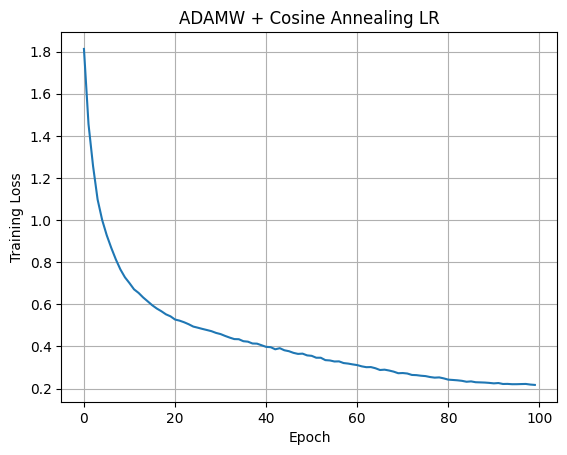

In [51]:
# Plot training loss
plt.plot(loss_log)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid()
plt.title("ADAMW + Cosine Annealing LR")
plt.show()

In [62]:
# Measure test accuracy and inference speed
model.eval()
correct = 0
total = 0
inference_times = np.zeros((len(testloader.dataset), 1))
with torch.no_grad():
    for i, (inputs, labels) in enumerate(testloader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        start_time = time.time()
        outputs = inference(model, inputs)
        end_time = time.time()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        inference_times[i] = (end_time - start_time) * 1000  # Batch inference time in milliseconds

acc = 100 * correct / total
 
print(f"Test accuracy: {acc:.2f}%")
print(f"Inference time: {np.mean(inference_times):.3f} ms")
print(f"Model file size: {get_file_size_kb(MODEL_PATH):.2f} KB")

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [57]:
from torchsummary import summary
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
        ReLUConvBN-6           [-1, 16, 32, 32]               0
              ReLU-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 16, 32, 32]           2,304
       BatchNorm2d-9           [-1, 16, 32, 32]              32
       ReLUConvBN-10           [-1, 16, 32, 32]               0
             ReLU-11           [-1, 16, 32, 32]               0
           Conv2d-12           [-1, 16, 32, 32]           2,304
      BatchNorm2d-13           [-1, 16, 32, 32]              32
       ReLUConvBN-14           [-1, 16,

**Fill-in the Results:**
- Model Size: __ KB
- Test Accuracy: __ %

**Provide brief notes (architecture choice, training decisions):**

# 2.2 Inference using ONNXRuntime (CPU)

Export your model to ONNX and run inference using ONNXRuntime (CPU).



In [63]:
# Dummy input for CIFAR-10 image shape
dummy_input = torch.randn(1, 3, 32, 32)

model.to("cpu")  # ONNX export requires CPU model

# Export to ONNX
torch.onnx.export(model, 
                  dummy_input, 
                  ONNX_PATH, 
                  opset_version=13, 
                  input_names=["input"],
                  output_names=["output"],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}, # Flexible batch size
                  verbose=False)

print("ONNX conversion complete!")

ONNX conversion complete!


In [64]:
# Create ONNX runtime session
ort_sess = onnxruntime.InferenceSession(ONNX_PATH)

# Measure test accuracy and inference speed
correct = 0
total = 0
inference_times = np.zeros((len(testloader.dataset), 1))
for i, (images, labels) in enumerate(testloader):
    images_np = images.numpy()
    start_time = time.time()
    outputs = ort_sess.run(None, {'input': images_np})
    end_time = time.time()
    logits = outputs[0]
    preds = np.argmax(logits, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)
    inference_times[i] = (end_time - start_time) * 1000  # Batch inference time in milliseconds

print(f"Test Accuracy: {100 * correct / total:.2f}%")
print(f"Inference time: {np.mean(inference_times):.3f} ms")
print(f"Model size: {get_file_size_kb(ONNX_PATH):.2f} KB")

Test Accuracy: 87.07%
Inference time: 0.260 ms
Model size: 409.94 KB


**Fill-in the Results:**
- ONNX Model Size: __ KB
- Test Accuracy (ONNX): __ %
- Inference Time (FP32 Original): __ ms/batch
- Inference Time (ONNX FP32): __ ms/batch

**Provide brief comparison/analysis:**

# 2.3 Post Training Quantization (Static)
Perform INT8 static quantization. Target: < 5% accuracy drop from FP32.

In [ ]:
# A calibration reader that feeds 300 sample images to compute static scale factors
class CIFARReader(CalibrationDataReader):
    def __init__(self, dataset, input_name, num_samples=300):
        self.input_name = input_name
        self.data = []
        for i in range(num_samples):
            img, _ = dataset[i]
            self.data.append({input_name: img.unsqueeze(0).numpy()})
        self.enum = iter(self.data)

    def get_next(self):
        return next(self.enum, None)

model = onnx.load(ONNX_PATH)    # Input ONNX model
input_name = model.graph.input[0].name
dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
reader = CIFARReader(dataset, input_name)

# Run static quantization
quantize_static(
    model_input=ONNX_PATH,
    model_output=STATIC_INT8_PATH,
    calibration_data_reader=reader,
    weight_type=QuantType.QInt8
)

print("Static quantization complete!")

Files already downloaded and verified


Static quantization complete!


In [ ]:
# Create ONNX runtime session
ort_sess = onnxruntime.InferenceSession(STATIC_INT8_PATH)

# Measure test accuracy and inference speed
correct = 0
total = 0
inference_times = np.zeros((len(testloader.dataset), 1))

for i, (images, labels) in enumerate(testloader):
    images_np = images.numpy()
    start_time = time.time()
    outputs = ort_sess.run(None, {'input': images_np})
    end_time = time.time()
    logits = outputs[0]
    preds = np.argmax(logits, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)
    inference_times[i] = (end_time - start_time) * 1000  # Batch inference time in milliseconds

print(f"Test Accuracy: {100 * correct / total:.2f}%")
print(f"Inference time: {np.mean(inference_times):.3f} ms")
print(f"Static INT8 Model size: {get_file_size_kb(STATIC_INT8_PATH):.2f} KB")

**Fill-in the Results:**
- INT8 Model Size: __ KB
- INT8 Test Accuracy: __ %
- Accuracy Drop: __ %
- Inference Time (INT8): __ ms/batch

**Quantization settings used:**

# **OPTIONAL - BONUS** 2.4 Post Training Quantization (Dynamic)

*(Optional)* Perform INT8 dynamic quantization.

Code cell below takes ~20-30 seconds to run

In [70]:
# Run dynamic quantization
quantize_dynamic(
    model_input=ONNX_PATH,
    model_output=DYNAMIC_INT8_PATH,
    weight_type=QuantType.QUInt8    # Currently ConvInt operation is only supported for unsigned integers
)

print("Dynamic quantization complete!")

# Create ONNX runtime session
ort_sess = onnxruntime.InferenceSession(DYNAMIC_INT8_PATH)

# Measure test accuracy and inference speed
correct = 0
total = 0
inference_times = np.zeros((len(testloader.dataset), 1))

for i, (images, labels) in enumerate(testloader):
    images_np = images.numpy()
    start_time = time.time()
    outputs = ort_sess.run(None, {'input': images_np})
    end_time = time.time()
    logits = outputs[0]
    preds = np.argmax(logits, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)
    inference_times[i] = (end_time - start_time) * 1000  # Batch inference time in milliseconds

print(f"Test Accuracy: {100 * correct / total:.2f}%")
print(f"Inference time: {np.mean(inference_times):.3f} ms")
print(f"Dynamic INT8 Model size: {get_file_size_kb(DYNAMIC_INT8_PATH):.2f} KB")

Dynamic quantization complete!
Test Accuracy: 87.00%
Inference time: 1.435 ms
Dynamic INT8 Model size: 151.04 KB


**Results:**
- INT8 Model Size: __ KB
- INT8 Test Accuracy: __ %
- Accuracy Drop: __ %
- Inference Time (INT8): __ ms/batch

**Comparison with static quantization:**

# Summary Table

| Metric | FP32 (Original) | FP32 (ONNX) | INT8 Static | INT8 Dynamic (Optional) |
|--------|-----------------|-------------|-------------|--------------|
| Size (KB) | | | | |
| Accuracy (%) | | | | |
| Inference (ms) | | | | |